# E1 Motivational Analysis: Whisfusion Decoder Error Characterisation

Analyses to motivate Experiment 1 (text-level diffusion): characterising how and where the Whisfusion decoder fails.

- **A**: Phonemic proximity of word substitution errors
- **C**: Per-step diffusion trajectory
- **D**: Token confidence calibration

## Setup

In [1]:
import sys
from pathlib import Path

root = Path("/rds/general/user/tsv22/home/accent-robust-asr").resolve()
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

In [2]:
import pandas as pd
import numpy as np
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
from scipy import stats
import jiwer
import g2p_en
from tqdm import tqdm
from difflib import SequenceMatcher

from src.utils.phonology import phones_to_feature_matrix, feature_edit_distance
from src.config import SPEAKER_L1

import nltk
nltk.data.path.insert(0, str(root / 'nltk_data'))

_G2P = g2p_en.G2p()
results_dir = Path("src/analysis/results")
results_dir.mkdir(parents=True, exist_ok=True)
(results_dir / "figures").mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Setup complete.")

Setup complete.


In [3]:
def norm(s: str) -> str:
    """Normalise text."""
    if not isinstance(s, str):
        return ""
    import re
    s = s.lower().strip()
    s = re.sub(r"[^\w\s]", "", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def words_to_phones(words: str) -> list:
    """Convert words to ARPAbet phones."""
    raw = _G2P(words)
    return [p.rstrip("012") for p in raw if p.strip() and p[0].isalpha()]

def compute_phone_distance(ref_word, pred_word):
    """Compute articulatory feature distance between two words."""
    try:
        ref_phones = words_to_phones(ref_word)
        pred_phones = words_to_phones(pred_word)
        
        if not ref_phones or not pred_phones:
            return np.nan
        
        ref_mat = phones_to_feature_matrix(ref_phones)
        pred_mat = phones_to_feature_matrix(pred_phones)
        dist = feature_edit_distance(ref_mat, pred_mat, indel_cost=0.5)
        return float(dist)
    except:
        return np.nan

---
## Analysis A: Phonemic Proximity of Substitution Errors

In [41]:
csv_path = root / "results/model_perf_comparison/whisfusion_finetuned_mask09_07_05_03_predictions.csv"
df = pd.read_csv(csv_path)

print(f"Loaded {len(df)} predictions")
print(f"L1 distribution:\n{df['l1'].value_counts()}")
print(f"\nWER: mean={df['utt_wer'].mean():.4f}, std={df['utt_wer'].std():.4f}")

Loaded 7796 predictions
L1 distribution:
l1
Vietnamese    1132
Hindi         1132
Arabic        1132
English       1132
Korean        1131
Chinese       1130
Spanish       1007
Name: count, dtype: int64

WER: mean=0.1582, std=0.1594


In [5]:
def extract_word_substitutions(df_input):
    """Extract substitutions by word-level alignment."""
    substitutions = []
    for idx, row in tqdm(df_input.iterrows(), total=len(df_input), desc="Extracting"):
        ref = row['reference_norm']
        pred = row['prediction_norm']
        if not ref or not isinstance(ref, str) or not isinstance(pred, str):
            continue
        ref_words = ref.split()
        pred_words = pred.split()
        if not ref_words:
            continue
        matcher = SequenceMatcher(None, ref_words, pred_words)
        for tag, i1, i2, j1, j2 in matcher.get_opcodes():
            if tag == 'replace' and (i2 - i1) == 1 and (j2 - j1) == 1:
                substitutions.append((ref_words[i1], pred_words[j1]))
    return substitutions

subs = extract_word_substitutions(df)
print(f"Extracted {len(subs)} substitutions")
print(f"Examples: {subs[:10]}")

Extracting: 100%|██████████| 7796/7796 [00:00<00:00, 19634.85it/s]

Extracted 1678 substitutions
Examples: [('danger', 'the'), ('always', 'you'), ('back', 'his'), ('exclaimed', 'explained'), ('borealis', 'bore'), ('that', 'the'), ('clubbed', 'fairlyraged'), ('quickly', 'capital'), ('children', 'and'), ('the', 'a')]


In [6]:
sub_distances = []
for ref_w, pred_w in tqdm(subs, desc="Computing distances"):
    dist = compute_phone_distance(ref_w, pred_w)
    if not np.isnan(dist):
        sub_distances.append(dist)

print(f"Valid distances: {len(sub_distances)} / {len(subs)}")
print(f"Mean: {np.mean(sub_distances):.4f}, Std: {np.std(sub_distances):.4f}")

Computing distances: 100%|██████████| 1678/1678 [00:04<00:00, 362.80it/s] 

Valid distances: 1678 / 1678
Mean: 1.0657, Std: 0.6731


In [7]:
vocab = set()
for idx, row in df.iterrows():
    vocab.update(norm(row['text']).split())
    vocab.update(norm(row['prediction']).split())

vocab = [w for w in vocab if len(words_to_phones(w)) > 0]
print(f"Vocabulary size: {len(vocab)}")

null_distances = []
for _ in tqdm(range(len(subs)), desc="Null distribution"):
    ref_w = np.random.choice(vocab)
    pred_w = np.random.choice(vocab)
    if ref_w != pred_w:
        dist = compute_phone_distance(ref_w, pred_w)
        if not np.isnan(dist):
            null_distances.append(dist)

print(f"Null distances: n={len(null_distances)}, mean={np.mean(null_distances):.4f}")

Vocabulary size: 4000


Null distribution: 100%|██████████| 1678/1678 [00:03<00:00, 540.49it/s]

Null distances: n=1677, mean=1.9647



=== Whisfusion Substitutions vs Random Pairs ===
Observed: n=1678, mean=1.0657
Null: n=1677, mean=1.9647
KS test: p=1.11e-178
✓ Whisfusion substitutions are PHONEMICALLY CLOSER than random pairs


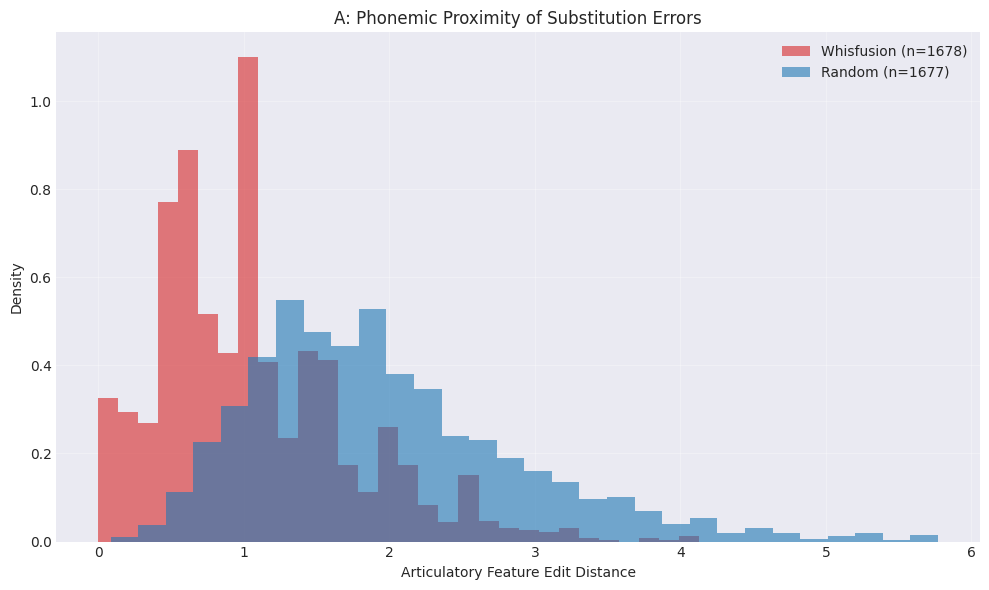

In [8]:
ks_stat, ks_pval = stats.ks_2samp(sub_distances, null_distances)
print(f"\n=== Whisfusion Substitutions vs Random Pairs ===")
print(f"Observed: n={len(sub_distances)}, mean={np.mean(sub_distances):.4f}")
print(f"Null: n={len(null_distances)}, mean={np.mean(null_distances):.4f}")
print(f"KS test: p={ks_pval:.2e}")
if ks_pval < 0.05 and np.mean(sub_distances) < np.mean(null_distances):
    print("✓ Whisfusion substitutions are PHONEMICALLY CLOSER than random pairs")

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(sub_distances, bins=30, alpha=0.6, label=f'Whisfusion (n={len(sub_distances)})', density=True, color='tab:red')
ax.hist(null_distances, bins=30, alpha=0.6, label=f'Random (n={len(null_distances)})', density=True, color='tab:blue')
ax.set_xlabel('Articulatory Feature Edit Distance')
ax.set_ylabel('Density')
ax.set_title('A: Phonemic Proximity of Substitution Errors')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(results_dir / 'figures' / 'e1_a_phonemic_proximity.png', dpi=150)
plt.show()

---
## Analyses C & D: Decoder Internals

In [43]:
internals_dir = Path(f"{root}/results/e1_decoder_internals")

if internals_dir.exists():
    internals_files = sorted(internals_dir.glob("*/*.pkl"))
    print(f"Found {len(internals_files)} internals files")
    
    internals_list = []
    for f in tqdm(internals_files, desc="Loading"):
        with open(f, 'rb') as fp:
            internals_list.append(pickle.load(fp))
    
    # Merge with predictions
    internals_df = pd.DataFrame([
        {'utterance_id': d['utterance_id'], 'speaker': d['speaker'], 'l1': d['l1']}
        for d in internals_list
    ])
    internals_df = internals_df.merge(
        df[['utterance_id', 'speaker', 'prediction', 'reference_norm', 'prediction_norm', 'utt_wer']],
        on=['utterance_id', 'speaker'], how='left'
    )
    print(f"Loaded {len(internals_df)} utterances")
else:
    print(f"No internals at {internals_dir}")
    print("Run: python -m src.training.evaluation.eval_whisfusion --save_decoder_internals")
    internals_list = None
    internals_df = None

Found 7796 internals files


Loading: 100%|██████████| 7796/7796 [01:24<00:00, 91.94it/s] 

Loaded 7796 utterances


In [44]:
# Debug: inspect raw internals format
sample = internals_list[0]
print("Sample internals keys:", sample.keys())
print(f"step_tokens shape: {sample['step_tokens'].shape}, dtype: {sample['step_tokens'].dtype}")
print(f"mask_history shape: {sample['mask_history'].shape}, dtype: {sample['mask_history'].dtype}")
print(f"\nStep 0 tokens (first 10): {sample['step_tokens'][0, :10]}")
print(f"Step 0 masks (first 10): {sample['mask_history'][0, :10]}")
print(f"\nStep 3 tokens (first 10): {sample['step_tokens'][3, :10]}")
print(f"Step 3 masks (first 10): {sample['mask_history'][3, :10]}")

Sample internals keys: dict_keys(['utterance_id', 'speaker', 'l1', 'step_tokens', 'mask_history', 'token_confidences', 'reference_tokens'])
step_tokens shape: (4, 256), dtype: int64
mask_history shape: (4, 256), dtype: bool

Step 0 tokens (first 10): [   1    2    2 2443 2443 2443 2443 2443 2443    2]
Step 0 masks (first 10): [False  True  True  True  True  True  True  True  True  True]

Step 3 tokens (first 10): [    1 13361   310  2443  9703 26203 29892 14920  2443  1379]
Step 3 masks (first 10): [False  True False False False False  True  True False False]


### Manual Inspection

In [46]:
from transformers import AutoTokenizer

# Load tokenizer (SMDM uses TinyLlama tokenizer)
print("Loading TinyLlama tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T")
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = 0
print(f"✓ Tokenizer loaded (vocab size: {len(tokenizer)})")
print(f"  mask_token_id: {tokenizer.mask_token_id}")

# Pre-index internals for fast lookup
print("Indexing internals...")
internals_index = {(d['speaker'], d['utterance_id']): d for d in internals_list}
print(f"✓ Indexed {len(internals_index)} utterances")

def show_step_by_step(internal_data, ref_text):
    """Display decoder outputs at each diffusion step with [MASK] for masked tokens."""
    step_tokens = internal_data['step_tokens']
    mask_history = internal_data['mask_history']
    token_confs = internal_data['token_confidences']
    ref_tokens = internal_data['reference_tokens']

    seq_len = min(step_tokens.shape[1], len(ref_tokens))
    step_tokens = step_tokens[:, :seq_len]
    ref_tokens = ref_tokens[:seq_len]
    mask_history = mask_history[:, :seq_len]

    print("\nStep-by-step decoding:")
    print("-" * 80)

    # Use mask token ID if available, otherwise use unk token
    if tokenizer.mask_token_id is not None:
        placeholder_id = tokenizer.mask_token_id
    else:
        placeholder_id = tokenizer.unk_token_id or 0

    for step in range(step_tokens.shape[0]):
        tokens_at_step = step_tokens[step].copy()
        masks_at_step = mask_history[step]
        
        # Replace masked positions with placeholder token
        tokens_for_decode = tokens_at_step.copy()
        tokens_for_decode[masks_at_step] = placeholder_id
        
        # Decode the full sequence without skipping special tokens
        text = tokenizer.decode(tokens_for_decode, skip_special_tokens=False)
        
        # Replace <unk> with [MASK]
        text = text.replace("<unk>", "[ ]")
        
        print(f"Step {step}: {text}")

    # Decode reference
    ref_text_decoded = tokenizer.decode(ref_tokens, skip_special_tokens=True)
    print(f"Ref:     {ref_text_decoded}")

    # Show confidence at each position
    print("\nToken confidences (final step):")
    print("-" * 80)
    final_tokens = step_tokens[-1]
    for i in range(min(10, seq_len)):
        is_correct = (final_tokens[i] == ref_tokens[i])
        marker = "✓" if is_correct else "✗"
        print(f"Pos {i}: token={int(final_tokens[i])} ref={int(ref_tokens[i])} conf={token_confs[i]:.3f} {marker}")
    if seq_len > 10:
        print(f"... ({seq_len - 10} more positions)")

def browse_high_wer(n=3, l1_filter=None, show_steps=True):
    """Browse high-WER utterances step-by-step."""
    if internals_df is None:
        print("No internals loaded")
        return

    df_browse = internals_df.dropna(subset=['utt_wer'])
    if l1_filter:
        df_browse = df_browse[df_browse['l1'] == l1_filter]

    top = df_browse.nlargest(n, 'utt_wer')
    print(f"Top {n} highest-WER" + (f" ({l1_filter})" if l1_filter else ""))
    for idx, row in tqdm(top.iterrows(), total=len(top), desc="Browsing"):
        print(f"\n{'='*80}")
        print(f"{row['speaker']}_{row['utterance_id']}: WER={row['utt_wer']:.1%} | {row['l1']}")
        print(f"Ref:  {row['reference_norm']}")
        print(f"Pred: {row['prediction_norm']}")

        if show_steps:
            key = (row['speaker'], row['utterance_id'])
            if key in internals_index:
                show_step_by_step(internals_index[key], row['reference_norm'])
            else:
                print("(internals not found)")

if internals_df is not None:
    browse_high_wer(n=100, show_steps=True)

Loading TinyLlama tokenizer...
✓ Tokenizer loaded (vocab size: 32000)
  mask_token_id: None
Indexing internals...
✓ Indexed 7796 utterances
Top 100 highest-WER


Browsing: 100%|██████████| 100/100 [00:00<00:00, 3262.83it/s]


BWC_arctic_a0028: WER=100.0% | Chinese
Ref:  robbery bribery fraud
Pred: robriy bri fray fraud

Step-by-step decoding:
--------------------------------------------------------------------------------
Step 0: <s>[ ][ ][ ][ ][ ][ ][ ]
Step 1: <s>[ ]ri[ ][ ][ ] fra[ ][ ]
Step 2: <s>[ ]ri[ ][ ]ri fray[ ]
Step 3: <s> Robri[ ] bri fra[ ] fra
Ref:     robbery bribery fraud

Token confidences (final step):
--------------------------------------------------------------------------------
Pos 0: token=1 ref=10832 conf=0.613 ✗
Pos 1: token=6417 ref=495 conf=0.996 ✗
Pos 2: token=374 ref=29891 conf=0.996 ✗
Pos 3: token=29891 ref=289 conf=1.000 ✗
Pos 4: token=289 ref=374 conf=0.996 ✗
Pos 5: token=374 ref=495 conf=1.000 ✗
Pos 6: token=5227 ref=29891 conf=1.000 ✗
Pos 7: token=29891 ref=5227 conf=0.996 ✗
Pos 8: token=5227 ref=566 conf=1.000 ✗

BWC_arctic_b0377: WER=100.0% | Chinese
Ref:  a scarlet loincloth
Pred: and

Step-by-step decoding:
--------------------------------------------------------------

### Analysis C: Per-step Trajectory

In [42]:
if internals_list is not None:
    print("Computing trajectory statistics...")
    trajectory_stats = []
    
    for internal_data in tqdm(internals_list, desc="Computing"):
        step_tokens = internal_data['step_tokens']
        ref_tokens = internal_data['reference_tokens']
        
        seq_len = min(step_tokens.shape[1], len(ref_tokens))
        step_tokens = step_tokens[:, :seq_len]
        ref_tokens = ref_tokens[:seq_len]
        
        for pos in range(seq_len):
            final_token = step_tokens[-1, pos]
            is_error = (final_token != ref_tokens[pos]) and (ref_tokens[pos] > 0)
            
            last_change = 0
            for step in range(step_tokens.shape[0] - 1, -1, -1):
                if step > 0 and step_tokens[step, pos] != step_tokens[step-1, pos]:
                    last_change = step
                    break
            
            oscillations = sum(1 for step in range(1, step_tokens.shape[0])
                              if step_tokens[step, pos] != step_tokens[step-1, pos])
            
            trajectory_stats.append({
                'is_error': is_error,
                'last_change_step': last_change,
                'oscillation_count': oscillations,
            })
    
    traj_df = pd.DataFrame(trajectory_stats)
    error_stats = traj_df[traj_df['is_error']]
    correct_stats = traj_df[~traj_df['is_error']]
    
    print(f"\nError positions (n={len(error_stats)}):")
    print(f"  Last change: mean={error_stats['last_change_step'].mean():.2f}")
    print(f"  Oscillations: mean={error_stats['oscillation_count'].mean():.2f}")
    
    print(f"\nCorrect positions (n={len(correct_stats)}):")
    print(f"  Last change: mean={correct_stats['last_change_step'].mean():.2f}")
    print(f"  Oscillations: mean={correct_stats['oscillation_count'].mean():.2f}")
    
    u_stat_lcs, p_lcs = stats.mannwhitneyu(error_stats['last_change_step'], correct_stats['last_change_step'])
    u_stat_osc, p_osc = stats.mannwhitneyu(error_stats['oscillation_count'], correct_stats['oscillation_count'])
    
    print(f"\nMann-Whitney U:")
    print(f"  Last change: p={p_lcs:.2e}" + (" ✓" if p_lcs < 0.05 else ""))
    print(f"  Oscillations: p={p_osc:.2e}" + (" ✓" if p_osc < 0.05 else ""))
else:
    print("Waiting for internals...")

Computing trajectory statistics...


Computing: 100%|██████████| 7796/7796 [00:00<00:00, 24775.62it/s]


Error positions (n=76830):
  Last change: mean=1.01
  Oscillations: mean=0.80

Correct positions (n=8043):
  Last change: mean=1.07
  Oscillations: mean=0.85

Mann-Whitney U:
  Last change: p=1.12e-12 ✓
  Oscillations: p=1.10e-13 ✓


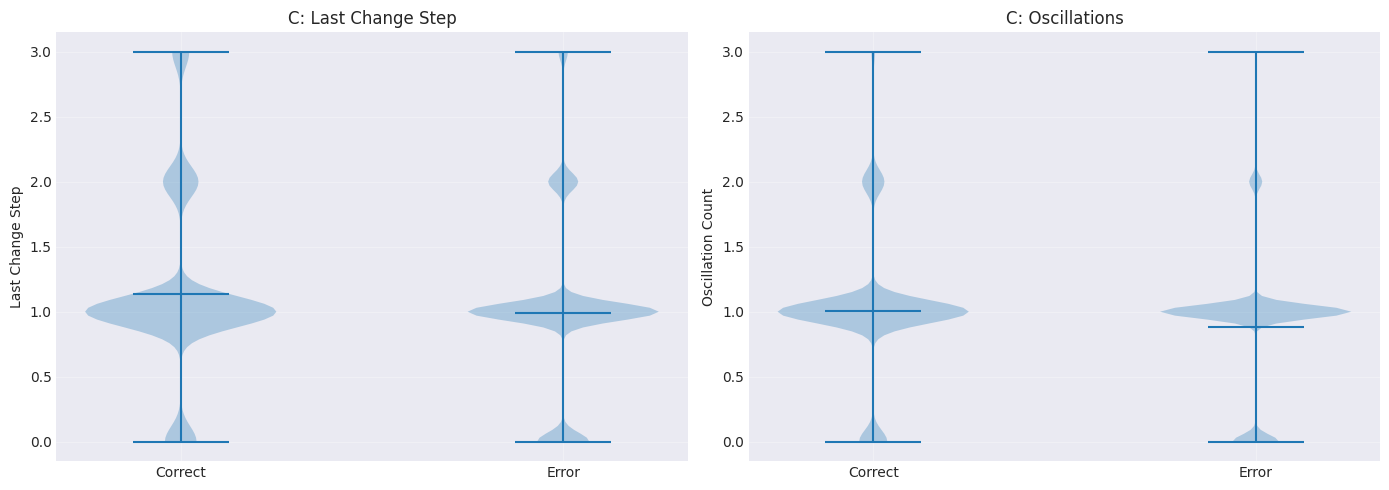

In [12]:
if 'traj_df' in locals():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].violinplot([correct_stats['last_change_step'].values, error_stats['last_change_step'].values], 
                       positions=[0, 1], showmeans=True)
    axes[0].set_xticks([0, 1])
    axes[0].set_xticklabels(['Correct', 'Error'])
    axes[0].set_ylabel('Last Change Step')
    axes[0].set_title('C: Last Change Step')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].violinplot([correct_stats['oscillation_count'].values, error_stats['oscillation_count'].values],
                       positions=[0, 1], showmeans=True)
    axes[1].set_xticks([0, 1])
    axes[1].set_xticklabels(['Correct', 'Error'])
    axes[1].set_ylabel('Oscillation Count')
    axes[1].set_title('C: Oscillations')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(results_dir / 'figures' / 'e1_c_trajectory.png', dpi=150)
    plt.show()

### Analysis D: Confidence Calibration

In [13]:
if internals_list is not None:
    print("Computing confidence calibration...")
    conf_stats = []
    
    for internal_data in tqdm(internals_list, desc="Computing"):
        token_confs = internal_data['token_confidences']
        step_tokens = internal_data['step_tokens']
        ref_tokens = internal_data['reference_tokens']
        
        seq_len = min(len(token_confs), len(ref_tokens))
        for pos in range(seq_len):
            is_error = (step_tokens[-1, pos] != ref_tokens[pos]) and (ref_tokens[pos] > 0)
            conf_stats.append({
                'confidence': token_confs[pos],
                'is_error': is_error,
            })
    
    conf_df = pd.DataFrame(conf_stats)
    
    # Calibration: bin by confidence
    conf_df['conf_bin'] = pd.cut(conf_df['confidence'], bins=10)
    calibration = conf_df.groupby('conf_bin', observed=True).agg({
        'confidence': 'mean',
        'is_error': lambda x: 1 - x.mean()  # accuracy
    }).dropna()
    
    # ECE
    ece = (abs(calibration['confidence'] - calibration['is_error']).sum() / len(calibration))
    
    print(f"\nConfidence calibration:")
    print(f"  ECE: {ece:.4f}")
    print(f"  Overconfident on errors: {conf_df[conf_df['is_error']]['confidence'].mean():.4f}")
    print(f"  Mean confidence on correct: {conf_df[~conf_df['is_error']]['confidence'].mean():.4f}")
else:
    print("Waiting for internals...")

Computing confidence calibration...


Computing: 100%|██████████| 7796/7796 [00:00<00:00, 114253.55it/s]


Confidence calibration:
  ECE: 0.4169
  Overconfident on errors: 0.9306
  Mean confidence on correct: 0.9514


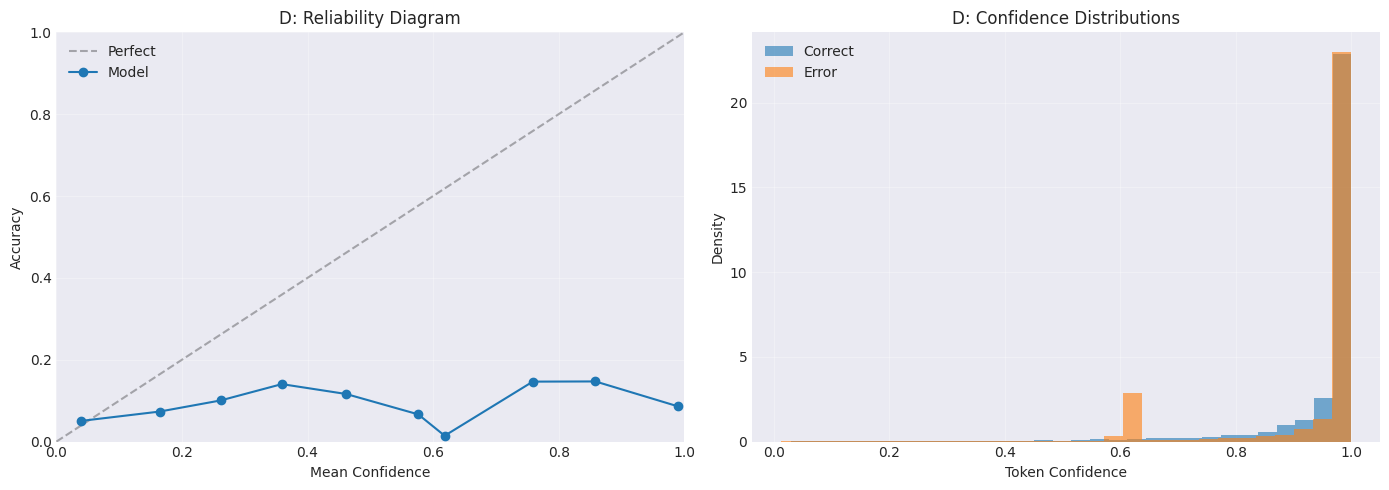

In [14]:
if 'conf_df' in locals():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Reliability diagram
    if len(calibration) > 0:
        axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfect')
        axes[0].plot(calibration['confidence'], calibration['is_error'], 'o-', label='Model')
        axes[0].set_xlabel('Mean Confidence')
        axes[0].set_ylabel('Accuracy')
        axes[0].set_title('D: Reliability Diagram')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        axes[0].set_xlim([0, 1])
        axes[0].set_ylim([0, 1])
    
    # Confidence distributions
    correct = conf_df[~conf_df['is_error']]['confidence']
    error = conf_df[conf_df['is_error']]['confidence']
    axes[1].hist(correct, bins=30, alpha=0.6, label='Correct', density=True)
    axes[1].hist(error, bins=30, alpha=0.6, label='Error', density=True)
    axes[1].set_xlabel('Token Confidence')
    axes[1].set_ylabel('Density')
    axes[1].set_title('D: Confidence Distributions')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(results_dir / 'figures' / 'e1_d_confidence.png', dpi=150)
    plt.show()